# Exploracion

En este notebook se evaluarán los resultados de los modelos entrenados anteriormente (Random Forest, y Multilayer Perceptron), y se compararán entre ellos mediante distintas métricas.

In [46]:
#Importacion de librerias
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    roc_auc_score
)

In [47]:
y_proba_mlp = np.load("../datos/processed/y_proba_mlp.npy")
y_proba_rf = np.load("../datos/processed/y_proba_rf.npy")

In [48]:
df_pred = pd.read_csv("../datos/processed/predicciones.csv")

df_pred.head()

,y_test,y_pred_mlp,y_pred_rf
0,BENIGN,PortScan,BENIGN
1,BENIGN,BENIGN,BENIGN
2,BENIGN,BENIGN,BENIGN
3,DDoS,DDoS,DDoS
4,BENIGN,BENIGN,BENIGN


In [49]:
y_test = df_pred["y_test"]
y_pred_mlp = df_pred["y_pred_mlp"]
y_pred_rf = df_pred["y_pred_rf"]

---
## Matrices de Confusion

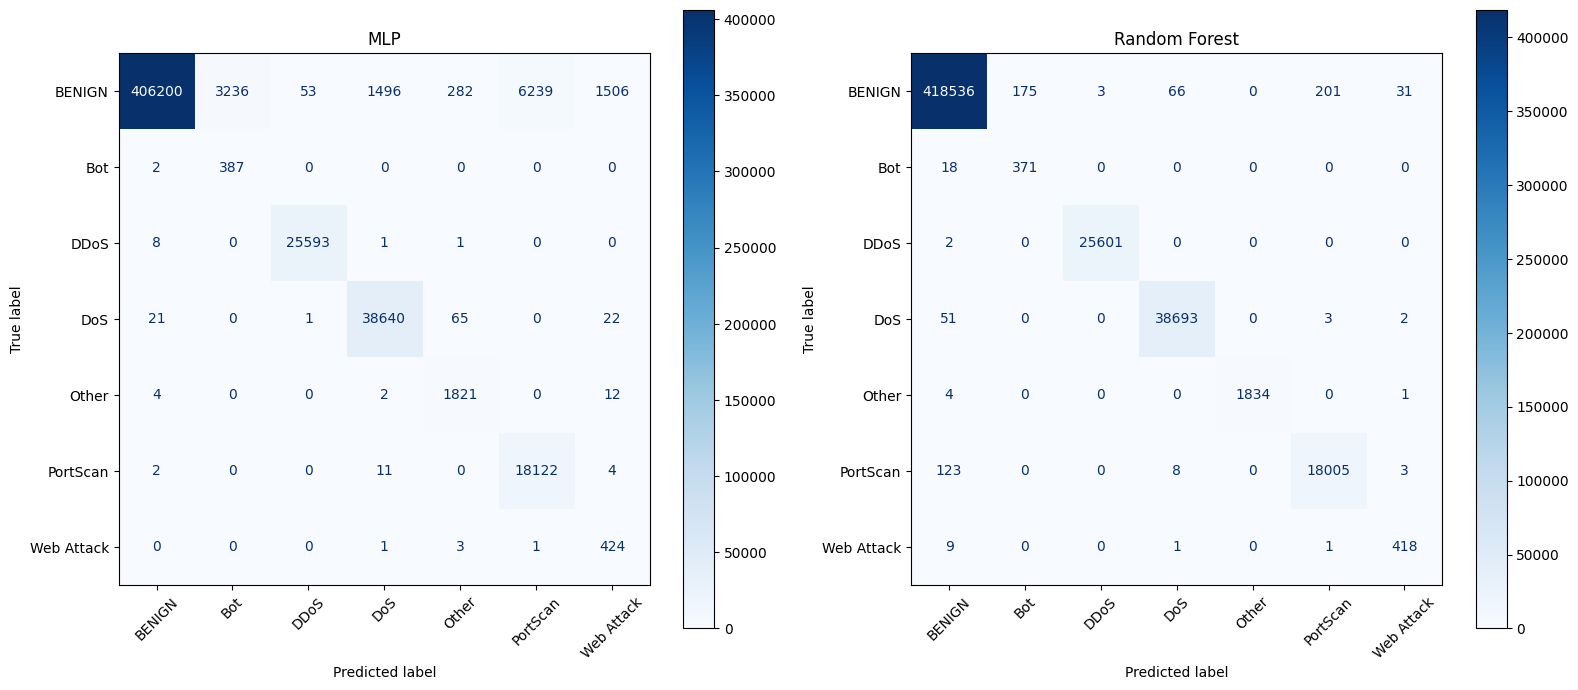

In [50]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
cm_rf = confusion_matrix(y_test, y_pred_rf)
clases = sorted(y_test.unique())
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# MLP
disp_mlp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mlp,
    display_labels=clases
)

disp_mlp.plot(
    ax=axes[0],
    cmap="Blues",
    xticks_rotation=45
)
axes[0].set_title("MLP")

# Random Forest
disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=clases
)

disp_rf.plot(
    ax=axes[1],
    cmap="Blues",
    xticks_rotation=45
)
axes[1].set_title("Random Forest")

plt.tight_layout()

plt.show()

### Matrices de confusion

Se presentan las matrices de confusión de ambos modelos, que compara la variable real en el eje y, comparado con el resultado predicho. Se puede observar que ambos modelos tuvieron un buen desempeño general, aunque el Random Forest parece tener mejor desempeño, principalmente en la clase benign. 

---

A continuación, se presenta el reporte de clasificación de ambos modelos

In [51]:
print("Classification Report - MLP\n")

print("Accuracy:", accuracy_score(y_test, y_pred_mlp))

print(
    classification_report(
        y_test,
        y_pred_mlp,
        digits=4
    )
)

Classification Report - MLP

Accuracy: 0.9742680894953983
              precision    recall  f1-score   support

      BENIGN     0.9999    0.9694    0.9844    419012
         Bot     0.1068    0.9949    0.1929       389
        DDoS     0.9979    0.9996    0.9988     25603
         DoS     0.9624    0.9972    0.9795     38749
       Other     0.8384    0.9902    0.9080      1839
    PortScan     0.7439    0.9991    0.8528     18139
  Web Attack     0.2154    0.9883    0.3538       429

    accuracy                         0.9743    504160
   macro avg     0.6950    0.9912    0.7529    504160
weighted avg     0.9858    0.9743    0.9786    504160



In [52]:
print("Classification Report - Random Forest\n")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(
    classification_report(
        y_test,
        y_pred_rf,
        digits=4
    )
)

Classification Report - Random Forest

Accuracy: 0.9986075848936845
              precision    recall  f1-score   support

      BENIGN     0.9995    0.9989    0.9992    419012
         Bot     0.6795    0.9537    0.7936       389
        DDoS     0.9999    0.9999    0.9999     25603
         DoS     0.9981    0.9986    0.9983     38749
       Other     1.0000    0.9973    0.9986      1839
    PortScan     0.9887    0.9926    0.9907     18139
  Web Attack     0.9187    0.9744    0.9457       429

    accuracy                         0.9986    504160
   macro avg     0.9406    0.9879    0.9609    504160
weighted avg     0.9987    0.9986    0.9986    504160



In [53]:
metricas = pd.DataFrame({
    "Modelo": ["MLP", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_mlp),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision (macro)": [
        precision_score(y_test, y_pred_mlp, average="macro"),
        precision_score(y_test, y_pred_rf, average="macro")
    ],
    "Recall (macro)": [
        recall_score(y_test, y_pred_mlp, average="macro"),
        recall_score(y_test, y_pred_rf, average="macro")
    ],
    "F1 (macro)": [
        f1_score(y_test, y_pred_mlp, average="macro"),
        f1_score(y_test, y_pred_rf, average="macro")
    ]
})

metricas

,Modelo,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,MLP,0.974268,0.694957,0.991243,0.752876
1,Random Forest,0.998608,0.940624,0.987903,0.960856


Al comparar ambos modelos, podemos observar que el Accuracy del Random Forest 0.99 es mayor al del MLP 0.97. Esto indica un mejor desempeño global del modelo Random Forest. Sin embargo, se utilizaron otras métricas, como los valores de precisión, recall y f1-score.

Algo que se puede notar es la dificultad del modelo MLP para clasificar las clases minoritarias, como 'Bot' y 'Web Atack'. Esto se ve por sus bajos valores de precisión y de f1-score. Por otro lado, el modelo Random Forest, si bien los valores más bajos de precisión y f1-score es en las clases 'bot' y 'Web Atack', no es tan afectado como el MLP.

La diferencia está también presente en el promedio macro. En general, se ve que el modelo Random Forest supera al modelo MLP en precisión macro y ponderada, y en f1-score macro y ponderada. El MLP por otro lado, tiene mayor recall. Esto significa que el MLP detecta una mayor proporción de las observaciones pertenecientes en cada clase. Esta particularidad se ve en la matriz de confusión, ya que el MLP deja pasar menos ataques como benign, aunque de mayores 'falsas alarmas'.


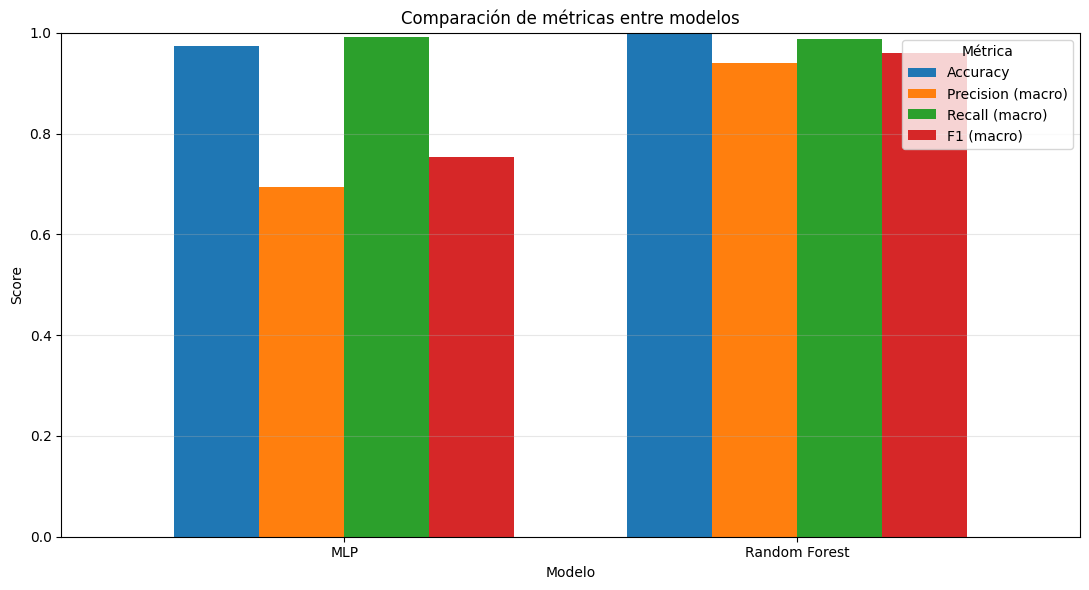

In [54]:
metricas_plot = metricas.set_index("Modelo")

ax = metricas_plot[
    ["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)"]
].plot(
    kind="bar",
    figsize=(11, 6),
    width=0.75
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Modelo")
plt.title("Comparación de métricas entre modelos")
plt.xticks(rotation=0)
plt.legend(title="Métrica")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Observacion visual de las métricas de cada modelo

---

# Curva ROC y AUC

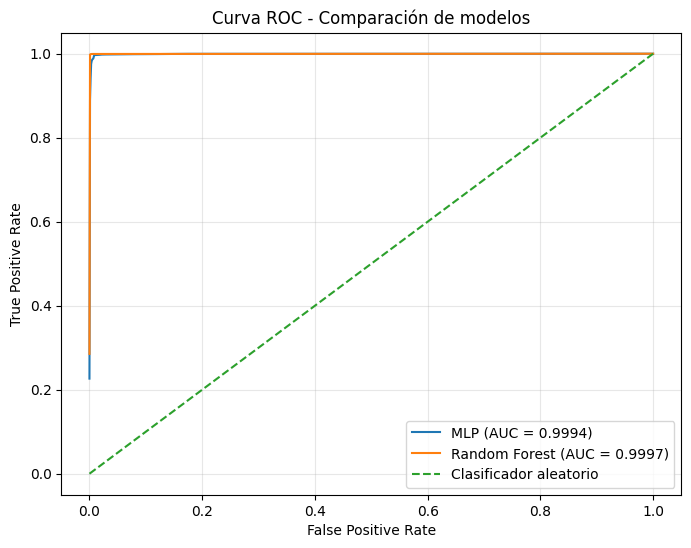

In [55]:
# Binarizar las etiquetas para clasificación multiclase
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# AUC macro
auc_mlp = roc_auc_score(
    y_test_bin,
    y_proba_mlp,
    multi_class="ovr",
    average="macro"
)

auc_rf = roc_auc_score(
    y_test_bin,
    y_proba_rf,
    multi_class="ovr",
    average="macro"
)

# Curva ROC macro para cada modelo
fpr_mlp = np.linspace(0, 1, 1000)
tpr_mlp = np.zeros_like(fpr_mlp)

fpr_rf = np.linspace(0, 1, 1000)
tpr_rf = np.zeros_like(fpr_rf)

# Calcular ROC para cada clase
for i in range(len(classes)):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_proba_mlp[:, i])
    tpr_mlp += np.interp(fpr_mlp, fpr_i, tpr_i)

    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_proba_rf[:, i])
    tpr_rf += np.interp(fpr_rf, fpr_i, tpr_i)

# Promedio entre clases
tpr_mlp /= len(classes)
tpr_rf /= len(classes)

# Gráfico
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_mlp,
    tpr_mlp,
    label=f"MLP (AUC = {auc_mlp:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Comparación de modelos")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

En este gráfico podemos observar visualmente que ambos modelos presentan una curva casi perfectamente cuadrada. Esto es lógico debido a que ambos modelos tuvieron desempeños mayores al 97%. La unica diferencia visible es en la punta, que el MLP baja un poco.

---

# Conclusiones Generales

En conclusión, ambos modelos presentaron resultados muy buenos. 

El modelo Random Forest presentó mejores resultados en general. Sin embargo, esto no es motivo para decir que es mejor modelo en general, pues hay que evaluar el costo de error. Algo que se pudo observar con las métricas es que el modelo MLP deja pasar menor cantidad de ataques como benign. Si el costo de recibir un ataque es muy alto, puede ser que la disminución de precisión puede ser conveniente si eso significa detectar más ataques, aunque eso genere más falsas alarmas.

En lo personal, considero que para servidores que trabajen con datos sensibles, como informacion de personas, o incluso datos militares por ejemplo, el modelo MLP resultaría más atractivo que el Random Forest, pues el costo de un ataque es más alto.